<a href="https://colab.research.google.com/github/tensorbytes0202/Deep-learning/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: RNN vs LSTM vs GRU Comparison on IMDB Dataset

### Objective:
Compare the performance of Simple RNN, LSTM, and GRU models on the IMDB movie review sentiment classification dataset, focusing on accuracy, loss, and training time.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

## 1. Data Loading and Preprocessing

We will load the IMDB dataset, which consists of movie reviews labeled as positive (1) or negative (0). Each review is represented as a sequence of integers, where each integer denotes a specific word in the vocabulary. We'll preprocess the data by padding sequences to a fixed length.

In [ ]:
# Parameters for data loading and preprocessing
max_words = 10000  # Vocabulary size (take only the top `max_words` most frequent words)
maxlen = 100       # Sequence length (pad/truncate reviews to this length)
embedding_dim = 64 # Dimension of the word embeddings

# Load the IMDB dataset
print(f"Loading IMDB dataset with {max_words} most frequent words...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_words)
print(f"Train sequences: {len(x_train)}, Test sequences: {len(x_test)}")

# Pad sequences to a fixed length
print(f"Padding sequences to length {maxlen}...")
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

Loading IMDB dataset with 10000 most frequent words...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train sequences: 25000, Test sequences: 25000
Padding sequences to length 100...
x_train shape: (25000, 100), y_train shape: (25000,)
x_test shape: (25000, 100), y_test shape: (25000,)


## 2. Model Building

We will build three different models: Simple RNN, LSTM, and GRU. Each model will start with an `Embedding` layer to convert word indices into dense vectors, followed by the respective recurrent layer, and finally a `Dense` layer with a sigmoid activation for binary classification.

In [ ]:
def build_model(model_type, vocab_size, embedding_dim, input_length):
    model = Sequential()
    # Embedding layer to convert word indices to dense vectors
    model.add(Embedding(vocab_size, embedding_dim, input_length=input_length))

    if model_type == "RNN":
        # SimpleRNN layer: often struggles with long-range dependencies
        model.add(SimpleRNN(32)) # 32 units
    elif model_type == "LSTM":
        # LSTM layer: designed to handle vanishing gradient problem and long-term dependencies
        model.add(LSTM(32))
    elif model_type == "GRU":
        # GRU layer: a simplified version of LSTM with fewer parameters
        model.add(GRU(32))
    else:
        raise ValueError("model_type must be 'RNN', 'LSTM', or 'GRU'")

    # Output layer for binary classification (sentiment: positive/negative)
    model.add(Dense(1, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

print("Model building function defined.")

Model building function defined.


## 3. Training and Evaluation

We will train each model for a few epochs and record their training time, loss, and accuracy on the test set. For demonstration purposes, we'll use 5 epochs, but more epochs might be needed for optimal performance.

In [ ]:
models = {}
histories = {}
training_times = {}

model_types = ["RNN", "LSTM", "GRU"]
epochs = 5 # Reduced epochs for a quicker demonstration
batch_size = 32

for model_type in model_types:
    print(f"\n--- Training {model_type} Model ---")
    model = build_model(model_type, max_words, embedding_dim, maxlen)
    model.summary()

    start_time = time.time()
    history = model.fit(x_train, y_train,
                                epochs=epochs,
                                batch_size=batch_size,
                                validation_split=0.2, # Use 20% of training data for validation
                                verbose=1) # Show training progress
    end_time = time.time()
    training_time = end_time - start_time

    loss, accuracy = model.evaluate(x_test, y_test, verbose=0) # Evaluate silently

    models[model_type] = model
    histories[model_type] = history
    training_times[model_type] = training_time

    print(f"\n{model_type} Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")
    print(f"{model_type} Training Time: {training_time:.2f} seconds")


--- Training RNN Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - accuracy: 0.7720 - loss: 0.4625 - val_accuracy: 0.8362 - val_loss: 0.3776
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.8949 - loss: 0.2674 - val_accuracy: 0.8360 - val_loss: 0.3653
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.9276 - loss: 0.1924 - val_accuracy: 0.8322 - val_loss: 0.4154
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.9549 - loss: 0.1293 - val_accuracy: 0.8304 - val_loss: 0.4473
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.9725 - loss: 0.0843 - val_accuracy: 0.8312 - val_loss: 0.5979

GRU Test Loss: 0.5987, Test Accuracy: 0.8283
GRU Training Time: 166.48 seconds


## 4. Comparison and Visualization

Here, we visualize the training and validation accuracy and loss for each model across epochs. We will also display a summary table comparing their test accuracy and training times.

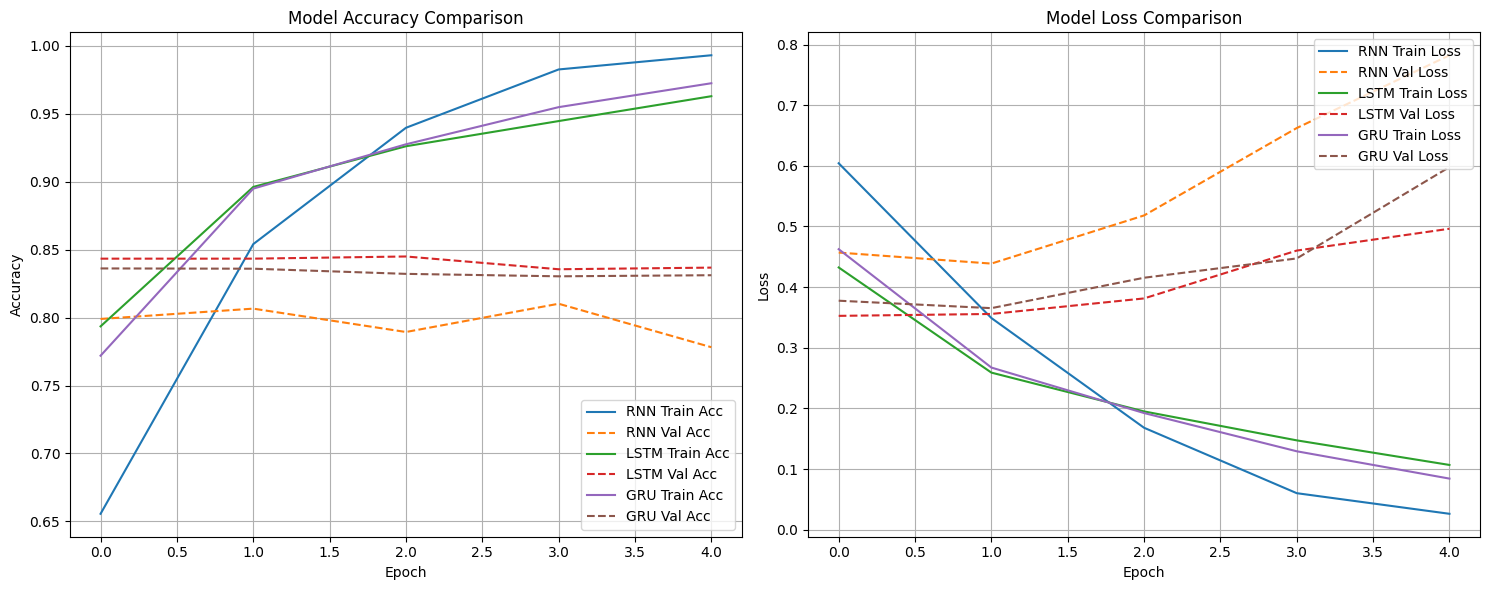

In [ ]:
plt.figure(figsize=(15, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
for model_type in model_types:
    plt.plot(histories[model_type].history['accuracy'], label=f'{model_type} Train Acc')
    plt.plot(histories[model_type].history['val_accuracy'], label=f'{model_type} Val Acc', linestyle='--')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
for model_type in model_types:
    plt.plot(histories[model_type].history['loss'], label=f'{model_type} Train Loss')
    plt.plot(histories[model_type].history['val_loss'], label=f'{model_type} Val Loss', linestyle='--')
plt.title('Model Loss Comparison')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

results = []
for model_type in model_types:
    # Evaluate on test set to get final accuracy and loss
    loss, accuracy = models[model_type].evaluate(x_test, y_test, verbose=0)
    results.append({
        'Model': model_type,
        'Test Loss': f"{loss:.4f}",
        'Test Accuracy': f"{accuracy:.4f}",
        'Training Time (s)': f"{training_times[model_type]:.2f}"
    })

results_df = pd.DataFrame(results)
print("\n--- Model Comparison Summary ---")
display(results_df)


--- Model Comparison Summary ---


,Model,Test Loss,Test Accuracy,Training Time (s)
0,RNN,0.7706,0.7819,94.07
1,LSTM,0.4985,0.8319,165.67
2,GRU,0.5987,0.8283,166.48
